# 05 — Single-cell validation of prioritized perturbation targets

This notebook validates prioritized perturbations and their target genes using optional single-cell evidence tables.
It is designed to be robust, GitHub-ready, and compatible with template files created earlier.

## What this notebook does

- Loads the final anticorrelation ranking from Step 04
- Maps prioritized perturbations to curated target genes
- Loads optional single-cell evidence tables
- Standardizes column names from multiple possible input formats
- Computes transparent gene-level and perturbation-level support scores
- Writes final validation tables and figures

## Optional input files

Expected under `data/processed/single_cell/`:

- `single_cell_target_expression.tsv`
- `single_cell_target_differential_expression.tsv`
- `single_cell_pathway_activity.tsv`

The notebook will continue as long as **at least one** table contains usable rows.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAVE_SEABORN = True
except Exception:
    HAVE_SEABORN = False

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
SC_DIR = PROJECT_ROOT / "data" / "processed" / "single_cell"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
SC_DIR.mkdir(parents=True, exist_ok=True)

ranking_file = RESULTS_TABLES / "final_anticorrelation_ranking.tsv"
expr_file = SC_DIR / "single_cell_target_expression.tsv"
de_file = SC_DIR / "single_cell_target_differential_expression.tsv"
pathway_file = SC_DIR / "single_cell_pathway_activity.tsv"

print("Project root:", PROJECT_ROOT)
print("Ranking file:", ranking_file)
print("Single-cell directory:", SC_DIR)

Project root: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery
Ranking file: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv
Single-cell directory: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell


## Load Step 04 ranking and define curated target mapping

The target mapping is intentionally transparent and editable. It captures the main mechanistic targets relevant to the current perturbations:

- **dexamethasone / budesonide** → glucocorticoid axis
- **tofacitinib / ruxolitinib** → JAK-family signaling

In [2]:
if not ranking_file.exists():
    raise FileNotFoundError(
        f"Required file not found: {ranking_file}\n"
        "Run 04_anticorrelation.ipynb first."
    )

ranking_df = pd.read_csv(ranking_file, sep="\t")
display(ranking_df.head())

TARGET_MAP = {
    "dexamethasone": ["NR3C1", "FKBP5", "TSC22D3"],
    "budesonide": ["NR3C1", "FKBP5", "TSC22D3"],
    "tofacitinib": ["JAK1", "JAK3", "TYK2"],
    "ruxolitinib": ["JAK1", "JAK2"],
}

def attach_targets(ranking_df, target_map):
    work = ranking_df.copy()
    if "perturbation_name" not in work.columns:
        raise KeyError("Ranking table must contain 'perturbation_name'.")
    work["perturbation_name_clean"] = work["perturbation_name"].astype(str).str.strip().str.lower()
    work["target_gene_list"] = work["perturbation_name_clean"].map(target_map).apply(
        lambda x: x if isinstance(x, list) else []
    )
    expanded = work.explode("target_gene_list").rename(columns={"target_gene_list": "target_gene"})
    expanded["target_gene"] = expanded["target_gene"].fillna("").astype(str).str.upper().str.strip()
    return work, expanded

ranking_df, ranked_targets_df = attach_targets(ranking_df, TARGET_MAP)
display(ranked_targets_df.head(10))

,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,pos_disease_reversal_fraction,neg_disease_reversal_fraction,weighted_reversal_strength,normalized_reversal_strength,mean_abs_disease_NES,mean_abs_perturbation_NES,reliability_factor,anticorrelation_score,confidence_flag,valid_for_ranking
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,1.000000,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,1.000000,0.333333,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,0.666667,0.000000,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True
3,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,0.666667,0.000000,-290.299429,-97.845963,1.910230,1.553165,0.266667,-1.751798,insufficient_shared_pathways,False


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,weighted_reversal_strength,normalized_reversal_strength,mean_abs_disease_NES,mean_abs_perturbation_NES,reliability_factor,anticorrelation_score,confidence_flag,valid_for_ranking,perturbation_name_clean,target_gene
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,budesonide,NR3C1
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,budesonide,FKBP5
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,budesonide,TSC22D3
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,dexamethasone,NR3C1
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,dexamethasone,FKBP5
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,dexamethasone,TSC22D3
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True,tofacitinib,JAK1
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True,tofacitinib,JAK3
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True,tofacitinib,TYK2
3,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,-290.299429,-97.845963,1.910230,1.553165,0.266667,-1.751798,insufficient_shared_pathways,False,ruxolitinib,JAK1


## Load optional single-cell evidence tables

This section accepts slightly different but common column names and standardizes them internally.

In [3]:
def read_tsv_if_exists(path):
    if not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, sep="\t")
        if df.empty:
            return pd.DataFrame()
        return df
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        return pd.DataFrame()

expr_df = read_tsv_if_exists(expr_file)
de_df = read_tsv_if_exists(de_file)
pathway_df = read_tsv_if_exists(pathway_file)

print("Expression table shape:", expr_df.shape)
print("Differential expression table shape:", de_df.shape)
print("Pathway activity table shape:", pathway_df.shape)

if not expr_df.empty:
    display(expr_df.head())
if not de_df.empty:
    display(de_df.head())
if not pathway_df.empty:
    display(pathway_df.head())

Expression table shape: (49, 6)
Differential expression table shape: (49, 6)
Pathway activity table shape: (0, 0)


,gene_symbol,cell_type,mean_expr,pct_expressing,dataset,comparison
0,NR3C1,B_cell,0.114308,0.187391,GSE214695,UC_vs_HC
1,FKBP5,B_cell,0.012132,0.026270,GSE214695,UC_vs_HC
2,TSC22D3,B_cell,0.720243,0.667250,GSE214695,UC_vs_HC
3,JAK1,B_cell,0.097013,0.161121,GSE214695,UC_vs_HC
4,JAK2,B_cell,0.007149,0.017513,GSE214695,UC_vs_HC


,gene_symbol,cell_type,log2FC,padj,dataset,comparison
0,JAK2,B_cell,0.216605,1.0,GSE214695,UC_vs_HC
1,NR3C1,B_cell,0.236048,1.0,GSE214695,UC_vs_HC
2,FKBP5,B_cell,-0.272742,1.0,GSE214695,UC_vs_HC
3,JAK3,B_cell,-0.111046,1.0,GSE214695,UC_vs_HC
4,TYK2,B_cell,-2.027540,1.0,GSE214695,UC_vs_HC


## Standardization helpers

These helpers make the notebook resilient to template files and minor naming differences.

In [4]:
def normalize_gene_symbol(series):
    return series.astype(str).str.strip().str.upper()

def find_first_column(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find any of {candidates} in columns: {list(df.columns)}")
    return None

def standardize_expression_table(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=[
            "gene_symbol", "cell_type", "mean_expr", "pct_expressing", "dataset", "comparison"
        ])

    work = df.copy()
    colmap = {}

    gene_col = find_first_column(work, ["gene_symbol", "gene", "target_gene"], required=True)
    cell_col = find_first_column(work, ["cell_type", "celltype", "cluster", "cell_population"], required=True)
    mean_col = find_first_column(work, ["mean_expr", "mean_expression", "avg_expression", "average_expression"], required=True)
    pct_col = find_first_column(work, ["pct_expressing", "pct_expr", "percent_expressing", "fraction_expressing"], required=False)
    dataset_col = find_first_column(work, ["dataset", "study", "source_dataset"], required=False)
    comp_col = find_first_column(work, ["comparison", "contrast"], required=False)

    colmap[gene_col] = "gene_symbol"
    colmap[cell_col] = "cell_type"
    colmap[mean_col] = "mean_expr"
    if pct_col: colmap[pct_col] = "pct_expressing"
    if dataset_col: colmap[dataset_col] = "dataset"
    if comp_col: colmap[comp_col] = "comparison"

    work = work.rename(columns=colmap).copy()

    for missing in ["pct_expressing", "dataset", "comparison"]:
        if missing not in work.columns:
            work[missing] = np.nan

    work["gene_symbol"] = normalize_gene_symbol(work["gene_symbol"])
    work["cell_type"] = work["cell_type"].astype(str).str.strip()
    work["mean_expr"] = pd.to_numeric(work["mean_expr"], errors="coerce")
    work["pct_expressing"] = pd.to_numeric(work["pct_expressing"], errors="coerce")

    keep = ["gene_symbol", "cell_type", "mean_expr", "pct_expressing", "dataset", "comparison"]
    work = work[keep].dropna(subset=["gene_symbol", "cell_type", "mean_expr"])
    return work.reset_index(drop=True)

def standardize_de_table(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=[
            "gene_symbol", "cell_type", "log2FC", "padj", "dataset", "comparison"
        ])

    work = df.copy()
    colmap = {}

    gene_col = find_first_column(work, ["gene_symbol", "gene", "target_gene"], required=True)
    cell_col = find_first_column(work, ["cell_type", "celltype", "cluster", "cell_population"], required=True)
    lfc_col = find_first_column(work, ["log2FC", "log2fc", "avg_log2FC", "avg_log2fc"], required=True)
    padj_col = find_first_column(work, ["padj", "adj_pval", "fdr", "FDR"], required=False)
    dataset_col = find_first_column(work, ["dataset", "study", "source_dataset"], required=False)
    comp_col = find_first_column(work, ["comparison", "contrast"], required=False)

    colmap[gene_col] = "gene_symbol"
    colmap[cell_col] = "cell_type"
    colmap[lfc_col] = "log2FC"
    if padj_col: colmap[padj_col] = "padj"
    if dataset_col: colmap[dataset_col] = "dataset"
    if comp_col: colmap[comp_col] = "comparison"

    work = work.rename(columns=colmap).copy()

    for missing in ["padj", "dataset", "comparison"]:
        if missing not in work.columns:
            work[missing] = np.nan

    work["gene_symbol"] = normalize_gene_symbol(work["gene_symbol"])
    work["cell_type"] = work["cell_type"].astype(str).str.strip()
    work["log2FC"] = pd.to_numeric(work["log2FC"], errors="coerce")
    work["padj"] = pd.to_numeric(work["padj"], errors="coerce")

    keep = ["gene_symbol", "cell_type", "log2FC", "padj", "dataset", "comparison"]
    work = work[keep].dropna(subset=["gene_symbol", "cell_type", "log2FC"])
    return work.reset_index(drop=True)

def standardize_pathway_table(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=[
            "Pathway", "cell_type", "activity_score", "padj", "dataset", "comparison", "direction"
        ])

    work = df.copy()
    colmap = {}

    pw_col = find_first_column(work, ["Pathway", "pathway", "Term"], required=True)
    cell_col = find_first_column(work, ["cell_type", "celltype", "cluster", "cell_population"], required=True)
    act_col = find_first_column(work, ["activity_score", "score", "NES", "pathway_score"], required=True)
    padj_col = find_first_column(work, ["padj", "adj_pval", "fdr", "FDR"], required=False)
    dataset_col = find_first_column(work, ["dataset", "study", "source_dataset"], required=False)
    comp_col = find_first_column(work, ["comparison", "contrast"], required=False)
    direction_col = find_first_column(work, ["direction", "status"], required=False)

    colmap[pw_col] = "Pathway"
    colmap[cell_col] = "cell_type"
    colmap[act_col] = "activity_score"
    if padj_col: colmap[padj_col] = "padj"
    if dataset_col: colmap[dataset_col] = "dataset"
    if comp_col: colmap[comp_col] = "comparison"
    if direction_col: colmap[direction_col] = "direction"

    work = work.rename(columns=colmap).copy()

    for missing in ["padj", "dataset", "comparison", "direction"]:
        if missing not in work.columns:
            work[missing] = np.nan

    work["Pathway"] = work["Pathway"].astype(str).str.strip()
    work["cell_type"] = work["cell_type"].astype(str).str.strip()
    work["activity_score"] = pd.to_numeric(work["activity_score"], errors="coerce")
    work["padj"] = pd.to_numeric(work["padj"], errors="coerce")

    keep = ["Pathway", "cell_type", "activity_score", "padj", "dataset", "comparison", "direction"]
    work = work[keep].dropna(subset=["Pathway", "cell_type", "activity_score"])
    return work.reset_index(drop=True)

expr_df_std = standardize_expression_table(expr_df)
de_df_std = standardize_de_table(de_df)
pathway_df_std = standardize_pathway_table(pathway_df)

print("Standardized expression shape:", expr_df_std.shape)
print("Standardized DE shape:", de_df_std.shape)
print("Standardized pathway shape:", pathway_df_std.shape)

Standardized expression shape: (49, 6)
Standardized DE shape: (49, 6)
Standardized pathway shape: (0, 7)


## Check whether any usable evidence exists

In [5]:
has_expr = not expr_df_std.empty
has_de = not de_df_std.empty
has_pathway = not pathway_df_std.empty

if not (has_expr or has_de or has_pathway):
    print("No populated single-cell evidence tables were found.")
    print("Templates may already exist in:", SC_DIR)
    print("\nFill at least one of these files and rerun:")
    print("- single_cell_target_expression.tsv")
    print("- single_cell_target_differential_expression.tsv")
    print("- single_cell_pathway_activity.tsv")
else:
    print("Single-cell evidence detected. Continuing.")

Single-cell evidence detected. Continuing.


## Summarize gene-level evidence

We summarize evidence only for genes associated with prioritized perturbations.

In [6]:
def summarize_expression(expr_df, genes_of_interest):
    if expr_df is None or expr_df.empty:
        return pd.DataFrame(columns=["gene_symbol", "cell_type", "mean_expr", "pct_expressing"])

    work = expr_df.copy()
    work["gene_symbol"] = normalize_gene_symbol(work["gene_symbol"])
    genes_of_interest = [str(g).strip().upper() for g in genes_of_interest if str(g).strip()]
    work = work[work["gene_symbol"].isin(genes_of_interest)].copy()

    if work.empty:
        return pd.DataFrame(columns=["gene_symbol", "cell_type", "mean_expr", "pct_expressing"])

    if "pct_expressing" not in work.columns:
        work["pct_expressing"] = np.nan

    work["mean_expr"] = pd.to_numeric(work["mean_expr"], errors="coerce")
    work["pct_expressing"] = pd.to_numeric(work["pct_expressing"], errors="coerce")

    summary = (
        work.groupby(["gene_symbol", "cell_type"], as_index=False)
        .agg(
            mean_expr=("mean_expr", "mean"),
            pct_expressing=("pct_expressing", "mean")
        )
    )
    return summary

def summarize_de(de_df, genes_of_interest):
    if de_df is None or de_df.empty:
        return pd.DataFrame(columns=["gene_symbol", "cell_type", "log2FC", "padj"])

    work = de_df.copy()
    work["gene_symbol"] = normalize_gene_symbol(work["gene_symbol"])
    genes_of_interest = [str(g).strip().upper() for g in genes_of_interest if str(g).strip()]
    work = work[work["gene_symbol"].isin(genes_of_interest)].copy()

    if work.empty:
        return pd.DataFrame(columns=["gene_symbol", "cell_type", "log2FC", "padj"])

    if "padj" not in work.columns:
        work["padj"] = np.nan

    work["log2FC"] = pd.to_numeric(work["log2FC"], errors="coerce")
    work["padj"] = pd.to_numeric(work["padj"], errors="coerce")

    summary = (
        work.groupby(["gene_symbol", "cell_type"], as_index=False)
        .agg(
            log2FC=("log2FC", "mean"),
            padj=("padj", "min")
        )
    )
    return summary

genes_of_interest = sorted(set(ranked_targets_df["target_gene"].dropna()) - {"NAN", ""})
expr_summary = summarize_expression(expr_df_std, genes_of_interest)
de_summary = summarize_de(de_df_std, genes_of_interest)

print("Genes of interest:", genes_of_interest)
display(expr_summary.head(20))
display(de_summary.head(20))

Genes of interest: ['FKBP5', 'JAK1', 'JAK2', 'JAK3', 'NR3C1', 'TSC22D3', 'TYK2']


,gene_symbol,cell_type,mean_expr,pct_expressing
0,FKBP5,B_cell,0.012132,0.026270
1,FKBP5,T_cell,0.024583,0.073494
2,FKBP5,endothelial,0.155051,0.134328
3,FKBP5,epithelial,0.012389,0.033654
4,FKBP5,myeloid,0.161654,0.123512
5,FKBP5,stromal,0.274419,0.166937
6,FKBP5,unassigned,0.059349,0.055614
7,JAK1,B_cell,0.097013,0.161121
8,JAK1,T_cell,0.180788,0.419277
9,JAK1,endothelial,0.161562,0.164179


,gene_symbol,cell_type,log2FC,padj
0,FKBP5,B_cell,-0.272742,1.000000e+00
1,FKBP5,T_cell,-24.701521,1.000000e+00
2,FKBP5,endothelial,0.052204,1.000000e+00
3,FKBP5,epithelial,-1.368268,1.000000e+00
4,FKBP5,myeloid,-0.874259,1.000000e+00
5,FKBP5,stromal,0.972981,1.000000e+00
6,FKBP5,unassigned,0.016731,1.000000e+00
7,JAK1,B_cell,-0.868265,4.758658e-01
8,JAK1,T_cell,-1.234913,5.497220e-05
9,JAK1,endothelial,0.823770,1.000000e+00


## Build gene-level validation table

A simple support score is used for transparency:

- higher target expression in a cell type increases support
- broader fraction of expressing cells increases support
- disease upregulation of a target can increase actionability for inhibitory perturbations
- low adjusted p-values increase confidence

In [7]:
def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    smin, smax = s.min(), s.max()
    if pd.isna(smin) or pd.isna(smax) or smax == smin:
        return pd.Series(np.where(s.notna(), 1.0, np.nan), index=s.index)
    return (s - smin) / (smax - smin)

gene_validation = ranked_targets_df.copy()
gene_validation["target_gene"] = gene_validation["target_gene"].astype(str).str.upper().str.strip()
gene_validation = gene_validation[gene_validation["target_gene"].ne("")].copy()

gene_validation = gene_validation.merge(
    expr_summary.rename(columns={"gene_symbol": "target_gene"}),
    on="target_gene", how="left"
)
gene_validation = gene_validation.merge(
    de_summary.rename(columns={"gene_symbol": "target_gene"}),
    on=["target_gene", "cell_type"], how="left"
)

if "mean_expr" not in gene_validation.columns:
    gene_validation["mean_expr"] = np.nan
if "pct_expressing" not in gene_validation.columns:
    gene_validation["pct_expressing"] = np.nan
if "log2FC" not in gene_validation.columns:
    gene_validation["log2FC"] = np.nan
if "padj" not in gene_validation.columns:
    gene_validation["padj"] = np.nan

# Force numeric types for robust scoring
for col in ["mean_expr", "pct_expressing", "log2FC", "padj"]:
    gene_validation[col] = pd.to_numeric(gene_validation[col], errors="coerce")

gene_validation["expr_score"] = minmax_scale(gene_validation["mean_expr"]).fillna(0)
gene_validation["pct_score"] = minmax_scale(gene_validation["pct_expressing"]).fillna(0)
gene_validation["de_up_score"] = minmax_scale(gene_validation["log2FC"].clip(lower=0)).fillna(0)

padj_clean = gene_validation["padj"].where(gene_validation["padj"] > 0)
neglog10_padj = -np.log10(padj_clean.astype(float))
gene_validation["de_significance_score"] = minmax_scale(neglog10_padj).fillna(0)

gene_validation["single_cell_support_score"] = (
    0.40 * gene_validation["expr_score"] +
    0.20 * gene_validation["pct_score"] +
    0.20 * gene_validation["de_up_score"] +
    0.20 * gene_validation["de_significance_score"]
)

def support_label(x):
    if pd.isna(x):
        return "No evidence"
    if x >= 0.66:
        return "Strong"
    if x >= 0.33:
        return "Moderate"
    if x > 0:
        return "Weak"
    return "No evidence"

gene_validation["single_cell_support_label"] = gene_validation["single_cell_support_score"].apply(support_label)

display(gene_validation.head(20))


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,mean_expr,pct_expressing,log2FC,padj,expr_score,pct_score,de_up_score,de_significance_score,single_cell_support_score,single_cell_support_label
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.114308,0.187391,0.236048,1.000000e+00,0.059433,0.202805,0.218573,0.000000,0.108049,Weak
1,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.115789,0.300000,-0.570280,2.237775e-01,0.060209,0.327516,0.000000,0.030342,0.095655,Weak
2,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.033407,0.046908,-4.099703,1.000000e+00,0.017069,0.047227,0.000000,0.000000,0.016273,Weak
3,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.057065,0.128606,-0.087965,1.000000e+00,0.029458,0.137704,0.000000,0.000000,0.039324,Weak
4,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.543292,0.349702,0.258911,1.000000e+00,0.284072,0.382560,0.239744,0.000000,0.238089,Weak
5,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.557773,0.316045,0.244875,1.000000e+00,0.291655,0.345286,0.226746,0.000000,0.231068,Weak
6,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.269883,0.229046,-0.544184,4.039755e-04,0.140901,0.248937,0.000000,0.158371,0.137822,Weak
7,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.012132,0.026270,-0.272742,1.000000e+00,0.005929,0.024370,0.000000,0.000000,0.007246,Weak
8,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.024583,0.073494,-24.701521,1.000000e+00,0.012449,0.076669,0.000000,0.000000,0.020313,Weak
9,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.0,...,0.155051,0.134328,0.052204,1.000000e+00,0.080769,0.144041,0.048339,0.000000,0.070783,Weak


## Build perturbation-level validation summary

In [8]:
perturbation_validation = (
    gene_validation.groupby(
        ["perturbation_id", "perturbation_name"], as_index=False
    )
    .agg(
        n_target_genes=("target_gene", "nunique"),
        n_supported_gene_rows=("single_cell_support_score", lambda s: int(pd.Series(s).notna().sum())),
        mean_target_support=("single_cell_support_score", "mean"),
        max_target_support=("single_cell_support_score", "max"),
        mean_expr_across_targets=("mean_expr", "mean"),
        mean_pct_expressing=("pct_expressing", "mean"),
        mean_target_log2FC=("log2FC", "mean"),
    )
)

if "anticorrelation_score" in ranking_df.columns:
    perturbation_validation = perturbation_validation.merge(
        ranking_df[["perturbation_id", "anticorrelation_score"]].drop_duplicates(),
        on="perturbation_id", how="left"
    )
else:
    perturbation_validation["anticorrelation_score"] = np.nan

perturbation_validation["combined_priority_score"] = (
    0.65 * minmax_scale(perturbation_validation["anticorrelation_score"]).fillna(0) +
    0.35 * minmax_scale(perturbation_validation["mean_target_support"]).fillna(0)
)

perturbation_validation = perturbation_validation.sort_values(
    ["combined_priority_score", "mean_target_support"],
    ascending=False
).reset_index(drop=True)

display(perturbation_validation)

,perturbation_id,perturbation_name,n_target_genes,n_supported_gene_rows,mean_target_support,max_target_support,mean_expr_across_targets,mean_pct_expressing,mean_target_log2FC,anticorrelation_score,combined_priority_score
0,drug_002,budesonide,3,21,0.207283,0.732294,0.463444,0.316292,-1.916822,0.487825,1.000000
1,drug_001,dexamethasone,3,21,0.207283,0.732294,0.463444,0.316292,-1.916822,-0.159091,0.873675
2,drug_005,ruxolitinib,2,14,0.089591,0.287154,0.149059,0.141110,-0.665192,-1.751798,0.212662
3,drug_004,tofacitinib,3,21,0.094451,0.302220,0.135768,0.127360,-1.427751,-2.840847,0.014452


## Optional pathway-level support summary

If pathway-activity input is present, this section summarizes inflammatory pathway evidence across cell types.

In [9]:
pathway_summary = pd.DataFrame()
if not pathway_df_std.empty:
    pathway_summary = (
        pathway_df_std.groupby(["Pathway", "cell_type"], as_index=False)
        .agg(
            activity_score=("activity_score", "mean"),
            padj=("padj", "min")
        )
        .sort_values(["activity_score", "padj"], ascending=[False, True])
        .reset_index(drop=True)
    )
    display(pathway_summary.head(20))
else:
    print("No pathway activity table provided; skipping pathway summary.")

No pathway activity table provided; skipping pathway summary.


## Save result tables

In [10]:
gene_out = RESULTS_TABLES / "final_single_cell_target_validation.tsv"
perturb_out = RESULTS_TABLES / "final_single_cell_perturbation_validation.tsv"
pathway_out = RESULTS_TABLES / "final_single_cell_pathway_validation.tsv"

gene_validation.to_csv(gene_out, sep="\t", index=False)
perturbation_validation.to_csv(perturb_out, sep="\t", index=False)
pathway_summary.to_csv(pathway_out, sep="\t", index=False)

print("Saved:")
print("-", gene_out)
print("-", perturb_out)
print("-", pathway_out)

Saved:
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_target_validation.tsv
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_perturbation_validation.tsv
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_single_cell_pathway_validation.tsv


## Figures

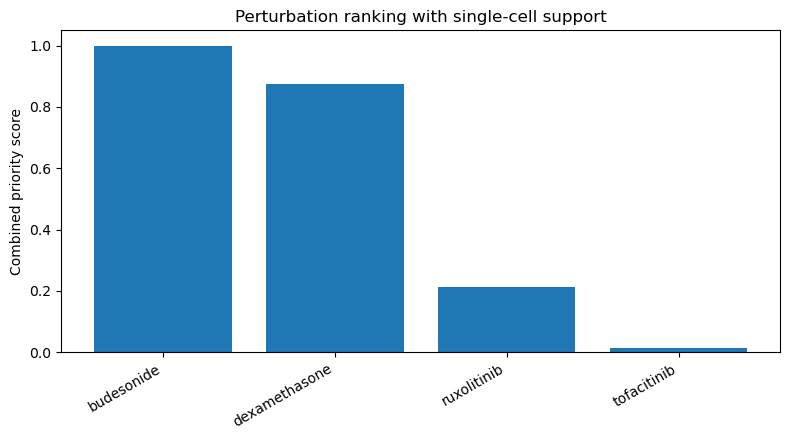

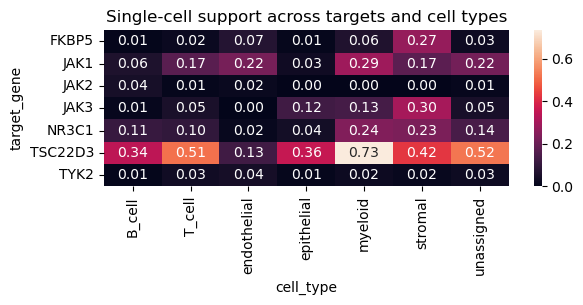

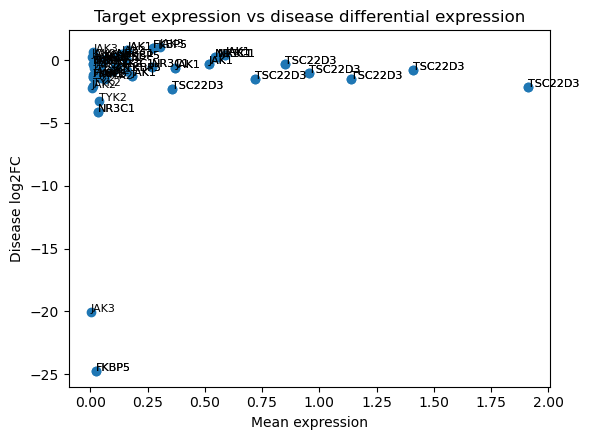

Figure outputs written to: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures


In [11]:
# Figure 1: ranked perturbation validation
plt.figure(figsize=(8, 4.5))
plot_df = perturbation_validation.copy()
plt.bar(plot_df["perturbation_name"], plot_df["combined_priority_score"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Combined priority score")
plt.title("Perturbation ranking with single-cell support")
plt.tight_layout()
fig1 = RESULTS_FIGURES / "single_cell_combined_priority_barplot.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: gene-level support heatmap-like table
heatmap_df = gene_validation.copy()
heatmap_df = heatmap_df.pivot_table(
    index="target_gene",
    columns="cell_type",
    values="single_cell_support_score",
    aggfunc="mean"
)

if not heatmap_df.empty:
    plt.figure(figsize=(max(6, 0.9 * heatmap_df.shape[1]), max(3, 0.45 * heatmap_df.shape[0])))
    if HAVE_SEABORN:
        sns.heatmap(heatmap_df, annot=True, fmt=".2f", cbar=True)
    else:
        plt.imshow(heatmap_df.values, aspect="auto")
        plt.colorbar(label="Support score")
        plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
        plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.title("Single-cell support across targets and cell types")
    plt.tight_layout()
    fig2 = RESULTS_FIGURES / "single_cell_target_support_heatmap.png"
    plt.savefig(fig2, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Heatmap skipped because no gene-level evidence was available.")

# Figure 3: expression vs DE
scatter_df = gene_validation.dropna(subset=["mean_expr", "log2FC"]).copy()
if not scatter_df.empty:
    plt.figure(figsize=(6, 4.5))
    plt.scatter(scatter_df["mean_expr"], scatter_df["log2FC"])
    for _, row in scatter_df.iterrows():
        plt.text(row["mean_expr"], row["log2FC"], row["target_gene"], fontsize=8)
    plt.xlabel("Mean expression")
    plt.ylabel("Disease log2FC")
    plt.title("Target expression vs disease differential expression")
    plt.tight_layout()
    fig3 = RESULTS_FIGURES / "single_cell_expression_vs_de_scatter.png"
    plt.savefig(fig3, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Expression-vs-DE scatter skipped because both measures were not available together.")

print("Figure outputs written to:", RESULTS_FIGURES)

## Interpretation

### Biological meaning

This notebook asks whether prioritized perturbations from the anticorrelation analysis are also supported by single-cell context.

A perturbation is more convincing when:
- its target genes are expressed in disease-relevant cell types,
- those targets are present in a substantial fraction of cells,
- and those targets are dysregulated in the disease state.

### Why this matters

Bulk pathway reversal is useful, but it does not reveal *which cell types* support the therapeutic hypothesis.
Single-cell validation adds resolution and helps connect the perturbation mechanism to specific inflammatory compartments.

### Expected interpretation in this project

- **Glucocorticoids** such as dexamethasone and budesonide are expected to reverse inflammatory programs and show support through the glucocorticoid receptor axis.
- **JAK inhibitors** such as tofacitinib and ruxolitinib are expected to be supported in immune cell types enriched for cytokine and interferon signaling.

### Limitations

- This step depends on the quality and relevance of the single-cell dataset.
- The support score is a transparent heuristic, not a formal causal model.
- Cell-type naming and dataset heterogeneity can influence the summary.
- If only one evidence table is provided, the support score reflects partial evidence.

## Final summary

The key output files are:

- `results/tables/final_single_cell_target_validation.tsv`
- `results/tables/final_single_cell_perturbation_validation.tsv`
- `results/tables/final_single_cell_pathway_validation.tsv`

These provide a clean, portfolio-ready extension from pathway anticorrelation to cell-type-aware validation.